In [1]:
! pip install opencv-python pixellib

In [20]:
# cv2: OpenCV 라이브러리로, 실시간 컴퓨터 비전을 목적으로 한 프로그래밍 라이브러리
# numpy(NumPy): 행렬이나 대규모 다차원 배열을 쉽게 처리할 수 있도록 지원하는 라이브러리. 데이터 구조 외에도 수치 계산을 위해 효율적으로 구현된 기능을 제공
# torch: PyTorch. 딥러닝 및 텐서 연산을 위한 라이브러리. 인공지능 모델을 만들거나 불러와 추론하는 도구
# torchvision: 이미지 변환 및 전처리를 위한 torchvision의 transform 모듈
# deeplabv3_resnet101: 사전 학습된 DeepLabV3 모델. 이미지를 분류하도록 학습된 모델
# matplotlib: 파이썬 프로그래밍 언어 및 수학적 확장 NumPy 라이브러리를 활용한 플로팅 라이브러리로, 데이터 시각화 도구

import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print('슝=3')

슝=3


이미지 크기: (1867, 2123, 3)


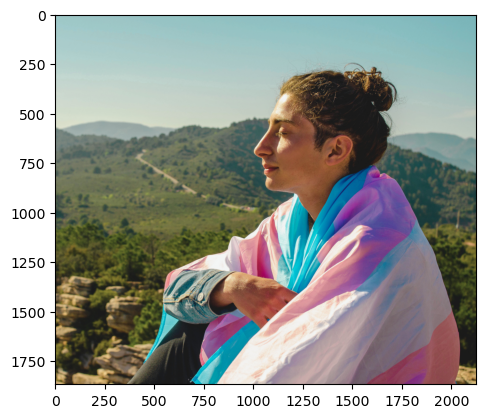

In [21]:
# 준비한 이미지 파일의 경로를 이용하여, 이미지 파일을 읽음
# cv2.imread(경로): 경로에 해당하는 이미지 파일을 읽어서 변수에 저장

# home_dir = os.getenv('/home/gmw/Documents/AIFFEL_Work/AIFFEL_Quest_eng/03_Computer_Vision/CV02')
# my_image_path = os.path.join(home_dir, '/images/front.png') # 본인 이미지가 있는 경로를 가지고 온다.
my_image_path = os.path.join(os.getcwd(), 'images', 'front.png')
img_orig = cv2.imread(my_image_path)

print(f"이미지 크기: {img_orig.shape}")

# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 이미지 색상 채널을 변경 (BGR 형식을 RGB 형식으로 변경)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시, 입력은 RGB(A) 데이터 혹은 2D 스칼라 데이터
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
# plt.show(): 현재 열려있는 모든 figure를 표시 (여기서 figure는 이미지, 그래프 등)
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

In [22]:
model = deeplabv3_resnet101(pretrained=True).eval()

/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [23]:
# 이미지 처리 인공지능 모델 중 사전 학습된 모델은 모델의 전처리 방식과 입력 크기 등이 사전 학습에 사용한 것과 동일하게 사용해야합니다.
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

In [ ]:
'''
전처리 코드를 이용해 우리가 사용할 이미지를 전처리해줍니다.
지금은 기억할 필요 없지만 우리가 사용할 DeepLab 모델을 비롯해 인공지능 모델 중 여러 데이터를 동시에(batch) 처리하는 것을 상정하는 경우
배치(batch) 차원을 추가해주어야합니다.
'''
input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)


원본 셀카 shape : (1867, 2123, 3)
번호 지도 shape : (1867, 2123)
번호 지도에 든 숫자들 : [ 0 15]


In [42]:
%%time

# 이제 모델에 이미지를 입력해 볼게요.
with torch.no_grad():
    output = model(input_tensor)["out"][0]      # shape: (21, 520, 520)
    output_predictions = output.argmax(0).byte().cpu().numpy() # 21개 중 제일 큰 놈의 번호(인덱스)를 고르기.
    # argmax: max(최댓값)이 아니라 최댓값이 있는 위치(번호)를 돌려 줌.

# 원본 크기로 Resize:  # shape: (21, 520, 520)으로 줄였던 520사이즈에서 원본 크기로 도로 늘리는 작업
output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)
''' 
INTER_NEAREST(최근접 이웃):
번호는 "15와 0 사이의 7.5" 같은 중간값이 있으면 안 됨(7.5번 물체는 없음). 
그래서 이웃 픽셀 값을 그대로 복사하는 방식으로 늘려서 번호가 정수로 유지되게 함.
'''

# 원본과 번호지도의 모양, 그리고 번호지도에 실제로 어떤 숫자들이 들어있는지 확인
print("원본 셀카 shape :", img_orig.shape)
print("번호 지도 shape :", output_predictions_resized.shape)
print("번호 지도에 든 숫자들 :", np.unique(output_predictions_resized))

원본 셀카 shape : (1867, 2123, 3)
번호 지도 shape : (1867, 2123)
번호 지도에 든 숫자들 : [ 0 15]
CPU times: user 5.57 s, sys: 92.9 ms, total: 5.66 s
Wall time: 362 ms


In [26]:
''' 
segmentAsPascalvoc라는 함수 이름에서 세그멘테이션 모델에 대한 힌트를 얻을 수 있는데요.
PASCAL VOC 데이터로 학습된 모델을 이용한다는 의미입니다.
모델마다 학습시킨 데이터에 따라 결괏값이 달라지므로 어떤 데이터를 학습시켰는지 확인하는 것은 매우 중요합니다.
'''

#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

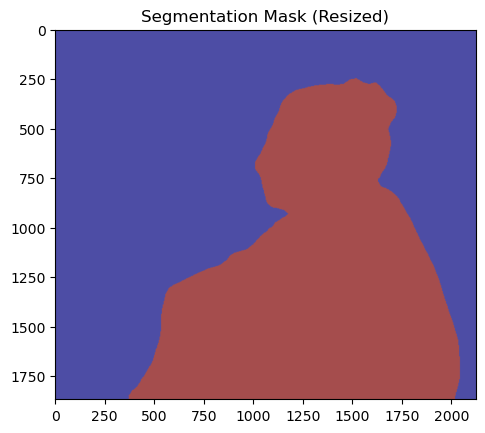

In [27]:
''' 
background를 제외하면 20개의 클래스가 있습니다. 따라서 20 의 의미는 tv 가 되겠네요! 0부터 시작하니까요.
우리는 이 중 사람(person) 라벨, 즉 15를 가진 영역만 검출해 내고 싶습니다. 이제 사람만 어떻게 추출할 수 있을지 알아봅시다.
아까 모델에서 나온 출력값을 살짝 살펴볼게요.
'''

plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [28]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0, 15], dtype=uint8)

In [29]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


In [30]:
''' 
output에는 세그멘테이션이 된 결과가 각각 다른 색상으로 담겨 있네요.
segvalues에는 class_ids와 masks가 있습니다.
class_ids를 통해 어떤 물체가 담겨 있는지 알 수 있군요!
이제 물체마다 output에 어떤 색상으로 나타나 있는지만 알아내면 될 것 같습니다.
'''


# 아래 코드를 이해하지 않아도 좋습니다
# PixelLib에서 그대로 가져온 코드입니다
# 주목해야 할 것은 생성 코드 결과물이예요!

#컬러맵 만들기
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:20]  # 생성한 20개의 컬러맵 출력

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

In [31]:
# DeepLab에 따르면 위와 같은 색을 사용했다고 하네요. 그럼 사람을 나타내는 15번째 색상은 무엇일까요?

colormap[15] #컬러맵 15에 해당하는 배열 출력 (pacalvoc에 LABEL_NAMES 15번째인 사람)

array([192, 128, 128])

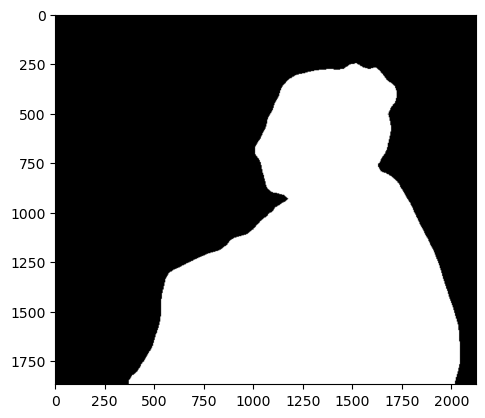

In [32]:
''' 
사람 외에도 다른 물체를 찾아내고 싶다면 colormap[class_id]처럼 찾아낼 수 있겠네요!
이제 사람만 표시된 마스크를 만들어봅시다.
'''


# output의 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False)이 됩니다
# 1과 0에 각각 255를 곱하였으므로 사람으로 예측된 픽셀은 255, 그렇지 않은 픽셀은 0
# cmap 값을 변경하면 다른 색상으로 확인이 가능함
seg_map = (output_predictions_resized == 15)  # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

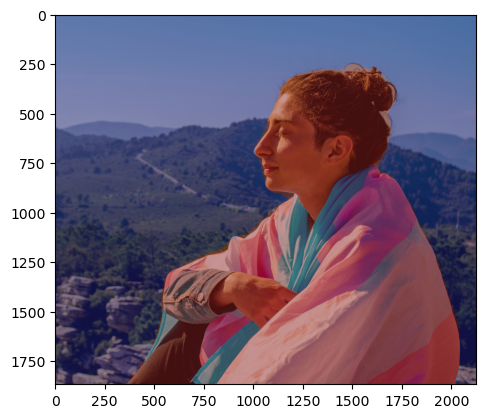

In [33]:
''' 
어떤가요? 3채널 가졌던 원본과는 다르게 채널 정보가 사라졌습니다.
이제 아래처럼 물체가 있는 위치는 1(True), 그 외에는 0(False)인 배열이 되었습니다.

[
[ 0 1 1 0 0 0 1 1 0 ],
[ 1 1 1 1 0 1 1 1 1 ],
[ 0 1 1 1 1 1 1 1 0 ],
[ 0 0 1 1 1 1 1 0 0 ],
[ 0 0 0 1 1 1 0 0 0 ]
]

원래 이미지와 겹쳐 보면 세그멘테이션이 얼마나 잘 되었는지 알아보기 쉬울 것 같네요.
'''

# 원본 이미지와 마스트를 적당히 합쳐봅니다
# 0.6과 0.4는 두 이미지를 섞는 비율입니다.

img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

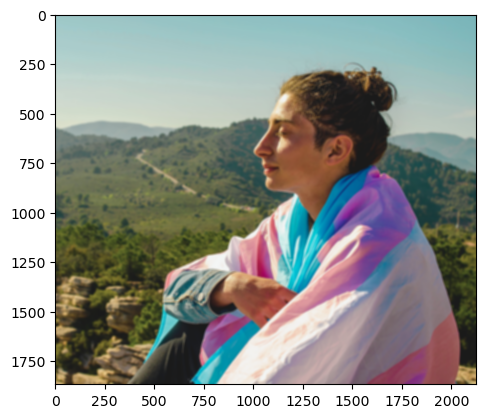

In [ ]:
# 이번에는 배경을 흐리게 만듭니다. blur() 함수를 이용합니다.

# (13,13)은 blurring kernel size를 뜻합니다
# 다양하게 바꿔보세요
img_orig_blur = cv2.blur(img_orig, (13, 13))   # 사진 전체가 흐려진 버전.

# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

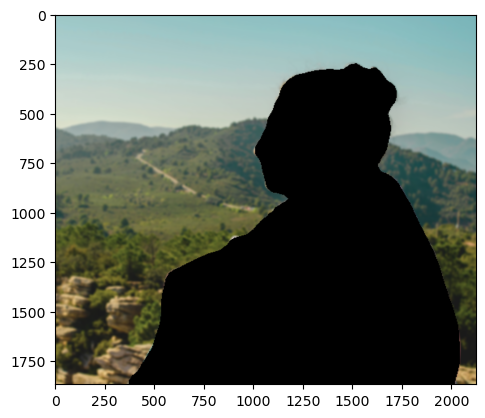

'\nbitwise_not 함수를 이용하면 이미지가 반전됩니다.\n원래 마스크에서는 배경이 0, 사람이 255였으니 bitwise_not 연산을 하고 나면 배경은 255, 사람은 0이 되겠죠?\n반전된 세그멘테이션 결과를 이용해서 이미지와 bitwise_and 연산을 수행하면 배경만 있는 영상을 얻을 수 있습니다.\n0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다.\n결국 사람이 사라지게 되는 거죠. \n'

In [ ]:
''' 흐려진 이미지에서 세그멘테이션 마스크를 이용해서 배경만 추출하겠습니다. '''

# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)   # (H,W) -> (H,W,3)

# cv2.bitwise_not(): 이미지가 반전됩니다. 배경이 0 사람이 255 였으나
# 연산을 하고 나면 배경은 255 사람은 0입니다.
img_bg_mask = cv2.bitwise_not(img_mask_color)   # bitwise_not(마스크) : 흑백 반전. 사람=0, 배경=255 로 뒤집힘

# cv2.bitwise_and()을 사용하면 배경만 있는 영상을 얻을 수 있습니다.
# 0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에
# 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다. 결국 사람이 사라지고 배경만 남아요!
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask) # bitwise_and(블러, 반전마스크) : 255 & 픽셀 = 픽셀, 0 & 픽셀 = 0
                                                          # 그래서 사람 자리는 0(까맣게)으로 지워지고 배경만 흐릿하게 남은 조각이 됨
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()  # 결과적으로 아래 셀의 np.where랑 같은 그림에 도달

'''
bitwise_not 함수를 이용하면 이미지가 반전됩니다.
원래 마스크에서는 배경이 0, 사람이 255였으니 bitwise_not 연산을 하고 나면 배경은 255, 사람은 0이 되겠죠?
반전된 세그멘테이션 결과를 이용해서 이미지와 bitwise_and 연산을 수행하면 배경만 있는 영상을 얻을 수 있습니다.
0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다.
결국 사람이 사라지게 되는 거죠. 
'''

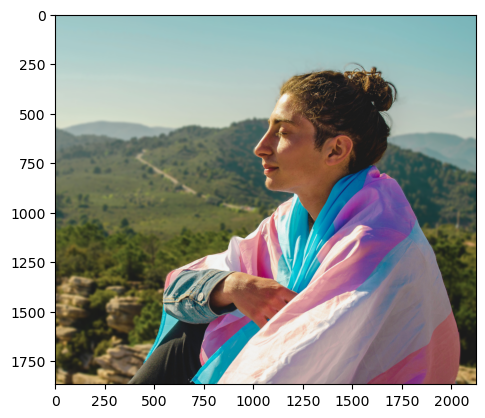

'\n세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고 아닌 영역은 블러된 이미지 값을 사용합니다. \nnp.where(조건, 참일때, 거짓일때)의 형식의 코드를 사용했네요. \n'

In [ ]:
''' 이제 배경 영상과 사람 영상을 합치기(img_concat)만 하면 되겠죠? '''

# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)   # 합성: np.where = "조건 보고 칸마다 골라 담기"
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

'''
  마스크 :  255  255   0    0    0      (앞 2칸=사람, 뒤 3칸=배경)
  원본   :   선   선   선   선   선
  블러   :   흐   흐   흐   흐   흐
          ─────────────────────────
  결과   :   선   선   흐   흐   흐      <- 사람칸=원본, 배경칸=블러

세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고 아닌 영역은 블러된 이미지 값을 사용합니다. 
np.where(조건, 참일때, 거짓일때)의 형식의 코드를 사용했네요. 
'''


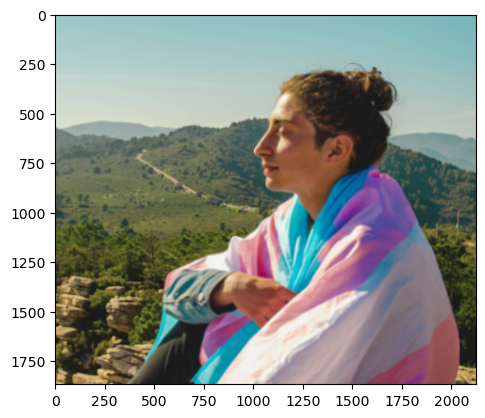

In [ ]:
''' 
멋진 인물 사진이 만들어졌습니다.
인물과 배경의 거리 차이가 있고 거리가 일정할수록 더 자연스러워 보인답니다.
'''

# Q. 이번에는 사람 부분을 블러로, 배경 부분을 원본으로 출력해볼까요?
# 힌트 : img_mask_color 옵션을 적절히 조정해주고, img_orig, img_orig_blur 를 활용하세요.
img_concat = np.where(img_mask_color == 255, img_orig_blur, img_orig) # 반대로 뒤집기. 
''' 
  img_concat = np.where(img_mask_color == 255, img_orig_blur, img_orig)
  #                                             └ 참:사람=블러 ┘ └거짓:배경=선명┘ : A와 B 자리만 바꿔서 -> 사람을 흐리게, 배경을 선명하게
'''
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()